# CNMF-E pipeline — part 3: extract neuronal components

Parts 1–2 motion-corrected a movie and picked parameters. This part runs the **full extraction**:

```
CORR/PNR seeding → ring-model background → spatial + temporal updates
                 → merging → auto-evaluation
```

To make the result easy to *check*, this notebook runs on the clean
`simple_medium` demo movie (128×128, 1000 frames, **12 neurons**, no
background artefacts, no motion), whose sidecar carries the **ground-truth**
footprints and traces. We extract, then validate the recovery against that
ground truth.

> **In your own pipeline** you would point `MOVIE` at the `mc.zarr` produced by
> part 1 (real recordings need the motion correction first). We use a clean,
> pre-registered simulated movie here purely so the recovery can be scored —
> real data has no ground truth. The harder, artefact-rich `realistic_medium`
> movie (and the knobs that tame it) is the subject of part 4.

Generate the demo movies once from the repo root if you haven't:

```bash
python generate_demo_movies.py
```

## 1. Imports & paths

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from minicnmfe.io import avi_to_zarr, open_zarr
from minicnmfe.pipeline import CNMFe, CNMFeParams
from minicnmfe.preprocess import correlation_pnr


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "minicnmfe").exists():
            return cand
    raise FileNotFoundError("Could not locate the minicnmfe repo root.")

REPO = find_repo_root()
DEMO = REPO / "demo_movies"
rel = lambda p: Path(p).relative_to(REPO)
MOVIE_NAME = "simple_medium"

AVI_PATH  = DEMO / f"{MOVIE_NAME}.avi"
ZARR_PATH = DEMO / f"{MOVIE_NAME}.zarr"
META_PATH = DEMO / f"{MOVIE_NAME}_meta.npz"
OUTPUT_DIR = DEMO / f"{MOVIE_NAME}_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert AVI_PATH.exists(), f"{AVI_PATH} not found — run `python generate_demo_movies.py`"
if not ZARR_PATH.exists():
    avi_to_zarr(AVI_PATH, ZARR_PATH, chunk_t=100, grayscale=True, dtype="uint8")
print(f"movie      : {rel(ZARR_PATH)}")
print(f"results dir: {rel(OUTPUT_DIR)}")

movie      : demo_movies/simple_medium.zarr
results dir: demo_movies/simple_medium_results


## 2. Load the movie into RAM

Extraction works on an in-RAM `(T, H, W)` float32 array. Peak RAM is roughly
`T · H · W · 4` bytes plus small per-batch buffers — trivial here, but for
60k+ frame recordings see the streaming section at the end.

In [2]:
z = open_zarr(ZARR_PATH)
T, H, W = z.shape
movie = np.asarray(z, dtype=np.float32)
print(f"movie : {movie.shape}  {movie.dtype}   (~{movie.nbytes / 1e6:.0f} MB in RAM)")

movie : (1000, 128, 128)  float32   (~66 MB in RAM)


## 3. CORR / PNR diagnostic — where are the neurons?

Two summary images drive seeding:

- **CORR** — each pixel's local temporal correlation with its neighbours.
  Active somata light up; noise does not.
- **PNR** — peak-to-noise ratio of each pixel's trace.

Their product is the seed score. `sigma` is the neuron radius in pixels (the
single most important parameter); set it to match your cells.

In [3]:
SIGMA = 3.0

t0 = time.time()
cn, pnr = correlation_pnr(movie, sigma=SIGMA, center_psf=True, n_jobs=-1, stride=5)
print(f"CORR/PNR computed in {time.time() - t0:.1f}s")
print(f"  CORR range: [{cn.min():.3f}, {cn.max():.3f}]")
print(f"  PNR  range: [{pnr.min():.3f}, {pnr.max():.3f}]")

CORR/PNR computed in 0.3s
  CORR range: [-0.007, 1.000]
  PNR  range: [1.627, 6.775]


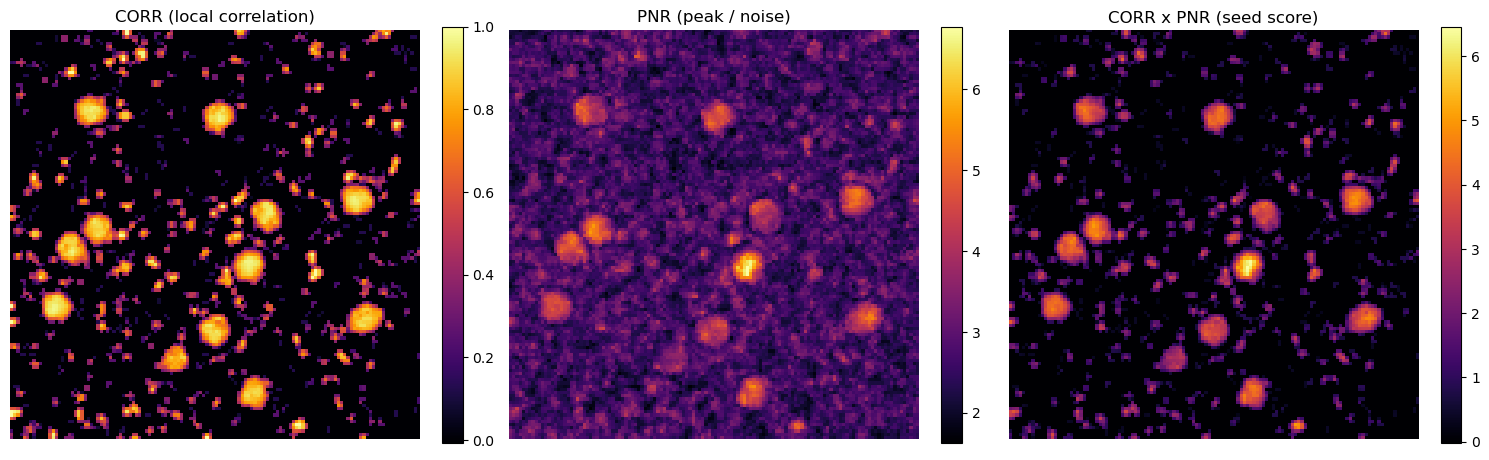

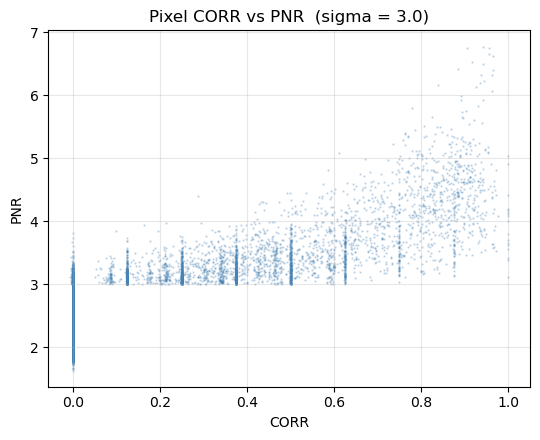

Pick `min_corr` / `min_pnr` just below the bright pixel cluster.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im0 = axes[0].imshow(cn, cmap="inferno")
axes[0].set_title("CORR (local correlation)"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(pnr, cmap="inferno")
axes[1].set_title("PNR (peak / noise)"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(cn * pnr, cmap="inferno")
axes[2].set_title("CORR x PNR (seed score)"); axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(cn.ravel(), pnr.ravel(), s=0.5, alpha=0.25, c="steelblue")
ax.set_xlabel("CORR"); ax.set_ylabel("PNR")
ax.set_title(f"Pixel CORR vs PNR  (sigma = {SIGMA})"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Pick `min_corr` / `min_pnr` just below the bright pixel cluster.")

## 4. Configure extraction parameters

The full set lives on `CNMFeParams`. The ones that matter most for a basic run:

| Field | Meaning |
|-------|---------|
| `sigma` | neuron radius (px) — sets the ring radius and seed PSF |
| `min_corr`, `min_pnr` | seed thresholds (lower → more candidates); set from the CORR/PNR distribution |
| `n_iter_main` | spatial+temporal+merge refinement cycles |
| `decay_time_ms` + `frame_rate_hz` | enable the physical Bayesian prior on the AR `g` |
| `min_pixel`, `auto_eval_snr_amp_thr` | **opt-in** post-fit ghost tagging (off by default; tags `accepted_mask`, never drops) |
| `n_jobs`, `device` | CPU workers / `"cuda"` |

> The acceptance gate is **off by default** (`auto_eval_snr_amp_thr=0`): `evaluate()`
> still records per-component quality (`snr_amp`, `pixel_count`) on `model.eval_info`
> for inspection, but tags nothing. Control ghosts upstream with `min_corr`/`min_pnr`;
> raise `auto_eval_snr_amp_thr` (~3) only if a noisy recording still seeds ghosts.

In [5]:
params = CNMFeParams(
    # Detection
    sigma=SIGMA,
    min_corr=0.78,
    min_pnr=7.0,

    # Refinement
    n_iter_main=2,
    n_iter_temporal=2,

    # Physical prior on the AR(1) decay g (preferred over fudge_factor).
    # Single-AP tau_decay (ms), somatic, approximate:
    #   GCaMP6f ~140  jGCaMP7f ~160  jGCaMP8f ~70  jGCaMP8m ~180
    #   jGCaMP8s ~350  GCaMP6s/7s ~1000
    decay_time_ms=180,
    frame_rate_hz=20,
    g_prior_weight=0.5,

    # Acceptance gate OFF (default): evaluate() still records per-component
    # snr_amp / pixel_count on model.eval_info, but tags nothing. This movie is
    # clean (no ghosts), so every extracted component is a real cell. Raise
    # auto_eval_snr_amp_thr (~3) to opt in to ghost tagging on a noisy recording.
    min_pixel=3,
    auto_eval_snr_amp_thr=0.0,

    # Greedy init runs on the full movie here (init_stride=1); on long
    # recordings leave it None to auto-subsample (max(1, T // 5000)).
    init_stride=1,

    n_jobs=-1,
    device="cpu",
)
print(f"sigma={params.sigma}  min_corr={params.min_corr}  min_pnr={params.min_pnr}  "
      f"n_iter_main={params.n_iter_main}")

sigma=3.0  min_corr=0.78  min_pnr=7.0  n_iter_main=2


## 5. Run extraction

In [6]:
model = CNMFe(params)
t0 = time.time()
model.fit(movie, do_motion_correction=False)
fit_elapsed = time.time() - t0

K = model.A.shape[1]
n_acc = int(model.accepted_mask.sum())
print(f"\nExtracted {K} components ({n_acc} accepted) in {fit_elapsed:.1f}s")
print(f"  A   : {model.A.shape}  sparse footprints (H*W x K)")
print(f"  C   : {model.C.shape}  OASIS-deconvolved traces")
print(f"  YrA : {model.YrA.shape}  residual; C + YrA = noisy projected trace")
print(f"  S   : {model.S.shape}  inferred spikes")

Extraction config: n_jobs=-1 device=cpu T=1000 H=128 W=128 streaming=no (movie materialised in RAM)
Estimating noise...


  [stage] noise estimation: 0.3s


Running greedy CORR-PNR initialization...
Using Bayesian g prior: decay_time_ms=180 frame_rate_hz=20 -> g_target=0.7575 (weight=0.5)
  Patch-parallel init: patch_size=48, overlap=12, n_jobs=16


  [stage] greedy init: 3.3s


  Found 12 initial components.
  [stage] AR g estimation: 0.0s


...

  12 components (0 merged).
  [stage] compute_W (b0 refresh): 0.0s


Final temporal update...


  [stage] final update_temporal: 0.1s


  [stage] final YrA projection: 0.0s


Auto-evaluation: 12/12 accepted (flagged 0: 0 fail pixel_count<3, 0 fail snr_amp<0.0). All components retained; filter via model.accepted_mask.
Done. Extracted 12 neurons.
Stage timings (total 5.9s):
  noise estimation            0.3s     4%
  greedy init                 3.3s    56%
  AR g estimation             0.0s     0%
  compute_W                   1.5s    26%
  merge                       0.0s     0% x3
  update_spatial              0.5s     9% x2
  update_temporal             0.2s     3% x2
  compute_W (b0 refresh)      0.0s     0% x2
  final update_temporal       0.1s     2%
  final YrA projection        0.0s     0%

Extracted 12 components (12 accepted) in 5.9s
  A   : (16384, 12)  sparse footprints (H*W x K)
  C   : (12, 1000)  OASIS-deconvolved traces
  YrA : (12, 1000)  residual; C + YrA = noisy projected trace
  S   : (12, 1000)  inferred spikes


## 6. Inspect results

`model.A` holds the spatial footprints, `model.C` the clean OASIS-deconvolved
traces, `model.YrA` the per-footprint residual (so `model.C_projected =
C + YrA` is the shape-faithful noisy trace), and `model.S` the inferred spikes.
`evaluate()` records per-component quality on `model.eval_info`, but with the
gate off (default) `model.accepted_mask` is all-True — so on this clean movie
"accepted" is simply every extracted cell. We still index through the mask for
the plots (it's the habit you'd keep if you opted the gate back in).

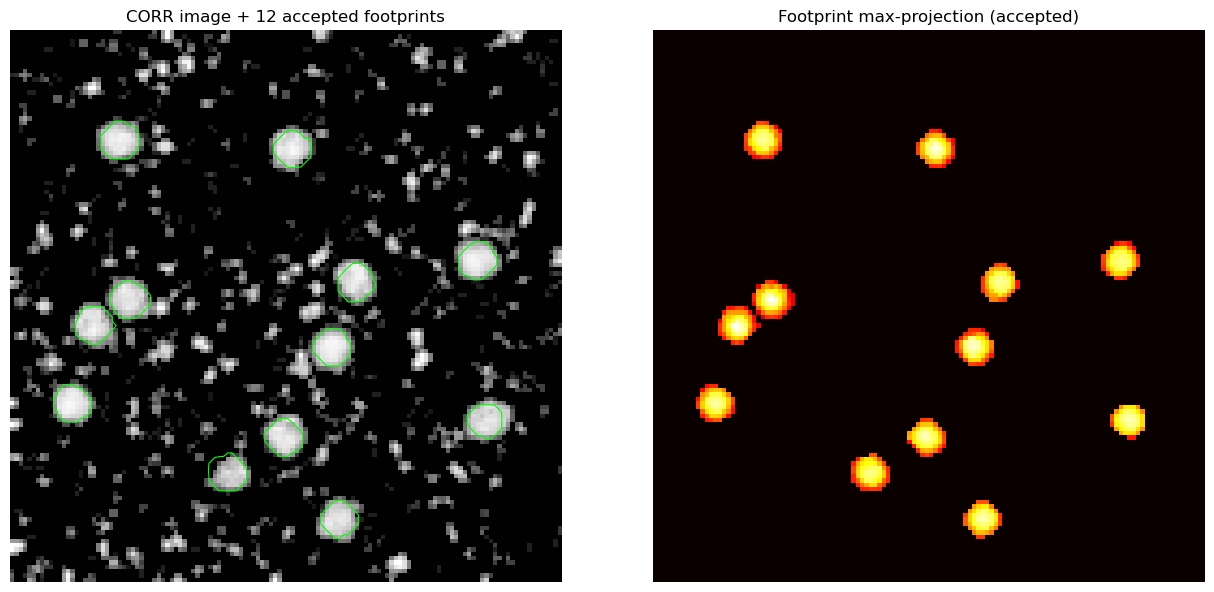

In [7]:
acc = np.flatnonzero(model.accepted_mask)
A_dense = model.A.toarray().reshape(H, W, K)
mean_img = movie.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(cn, cmap="gray")
for k in acc:
    fp = A_dense[..., k]
    if fp.max() > 0:
        axes[0].contour(fp, levels=[fp.max() * 0.3], colors="lime", linewidths=0.8)
axes[0].set_title(f"CORR image + {len(acc)} accepted footprints"); axes[0].axis("off")
axes[1].imshow(A_dense[..., acc].max(axis=2), cmap="hot")
axes[1].set_title("Footprint max-projection (accepted)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

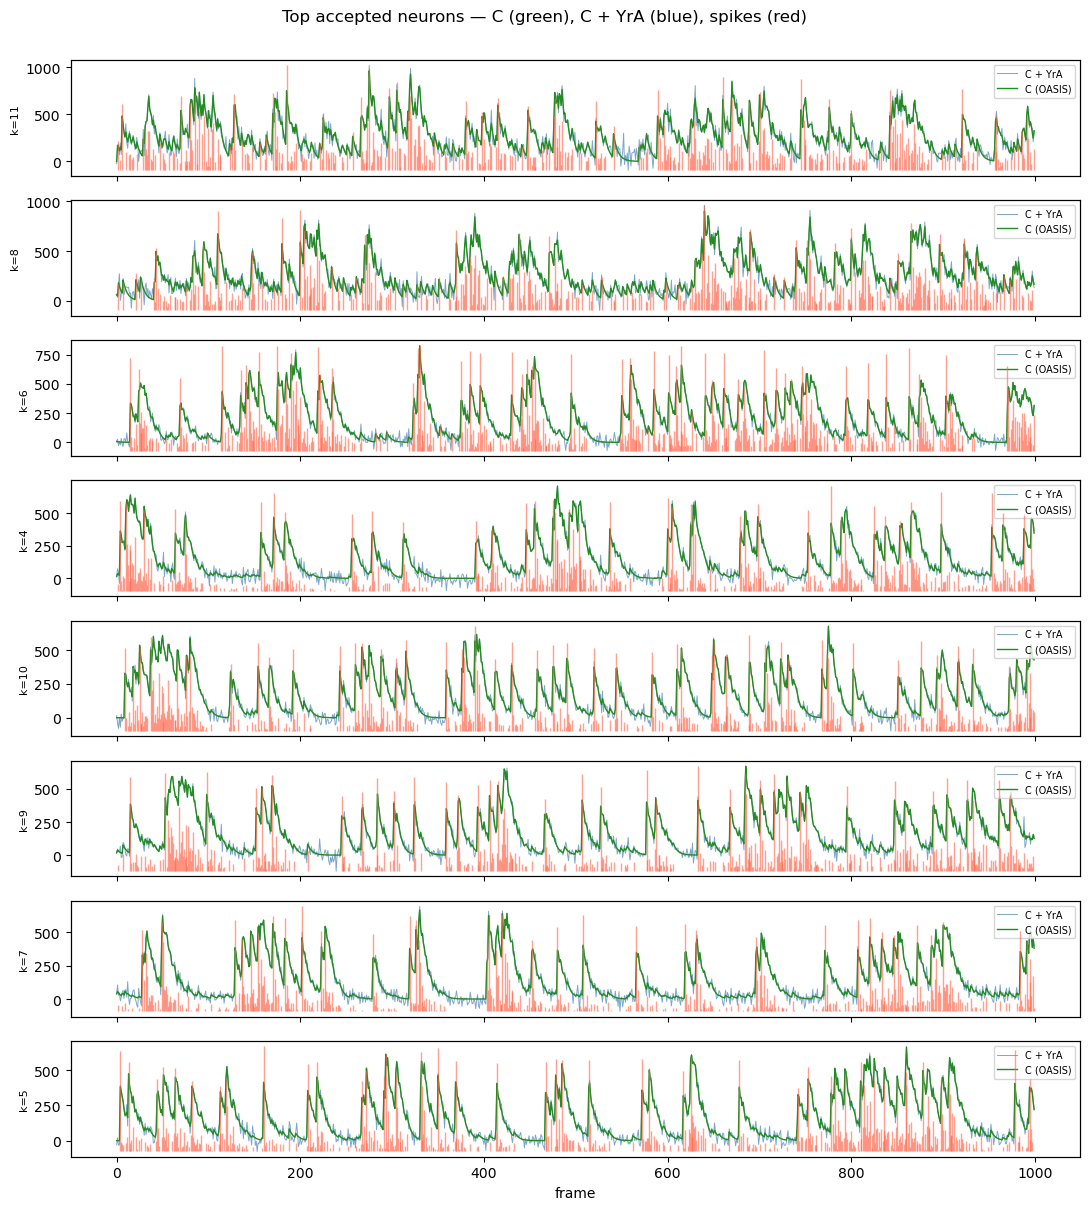

In [8]:
# Brightest accepted neurons: C (clean), C + YrA (noisy projected), S (spikes).
N_TRACES = min(8, len(acc))
peak = model.C[acc].max(axis=1)
top = acc[np.argsort(-peak)[:N_TRACES]]
C_proj = model.C_projected

fig, axes = plt.subplots(N_TRACES, 1, figsize=(11, 1.5 * N_TRACES), sharex=True)
for ax, k in zip(np.atleast_1d(axes), top):
    ax.plot(C_proj[k], lw=0.7, color="steelblue", alpha=0.7, label="C + YrA")
    ax.plot(model.C[k], lw=1.0, color="forestgreen", label="C (OASIS)")
    ax2 = ax.twinx()
    nz = np.flatnonzero(model.S[k])
    if nz.size:
        ax2.vlines(nz, 0, model.S[k][nz], color="tomato", alpha=0.6, lw=1.0)
    ax2.set_yticks([])
    ax.set_ylabel(f"k={k}", fontsize=8)
    ax.legend(loc="upper right", fontsize=7)
np.atleast_1d(axes)[-1].set_xlabel("frame")
plt.suptitle("Top accepted neurons — C (green), C + YrA (blue), spikes (red)", y=1.005)
plt.tight_layout(); plt.show()

## 7. Validate against ground truth

Because `simple_medium` is simulated, the sidecar stores the true footprints
(`A_true`) and traces (`C_true`). We match each ground-truth neuron to the
extracted component with the highest **spatial cosine similarity**, then report
recall and the per-neuron **trace correlation**. (On real data you don't have
this — judge quality by the CORR overlay and the `C` vs `C + YrA` agreement.)

In [9]:
meta = np.load(META_PATH)
A_true = meta["A_true"]          # (H*W, G)
C_true = meta["C_true"]          # (G, T)
G = C_true.shape[0]

A_acc = model.A.toarray()[:, acc]              # (H*W, n_acc)
C_acc = model.C_projected[acc]                 # (n_acc, T) shape-faithful
At = A_true / (np.linalg.norm(A_true, axis=0, keepdims=True) + 1e-9)
An = A_acc / (np.linalg.norm(A_acc, axis=0, keepdims=True) + 1e-9)
cos = At.T @ An                                # (G, n_acc) spatial cosine

pairs, used = [], set()
for g in range(G):
    for k in np.argsort(-cos[g]):
        if cos[g, k] < 0.4:
            break
        if k in used:
            continue
        used.add(k)
        r = np.corrcoef(C_true[g], C_acc[k])[0, 1]
        pairs.append((g, k, float(cos[g, k]), float(r)))
        break

recall = len(pairs) / G
trace_r = np.array([p[3] for p in pairs])
print(f"Recall: {len(pairs)}/{G} ground-truth neurons matched "
      f"(spatial cosine > 0.4)")
print(f"False positives (accepted, unmatched): {len(acc) - len(pairs)}")
print(f"Trace correlation (C+YrA vs truth): "
      f"median={np.median(trace_r):.3f}  min={trace_r.min():.3f}")

Recall: 12/12 ground-truth neurons matched (spatial cosine > 0.4)
False positives (accepted, unmatched): 0
Trace correlation (C+YrA vs truth): median=0.963  min=0.883


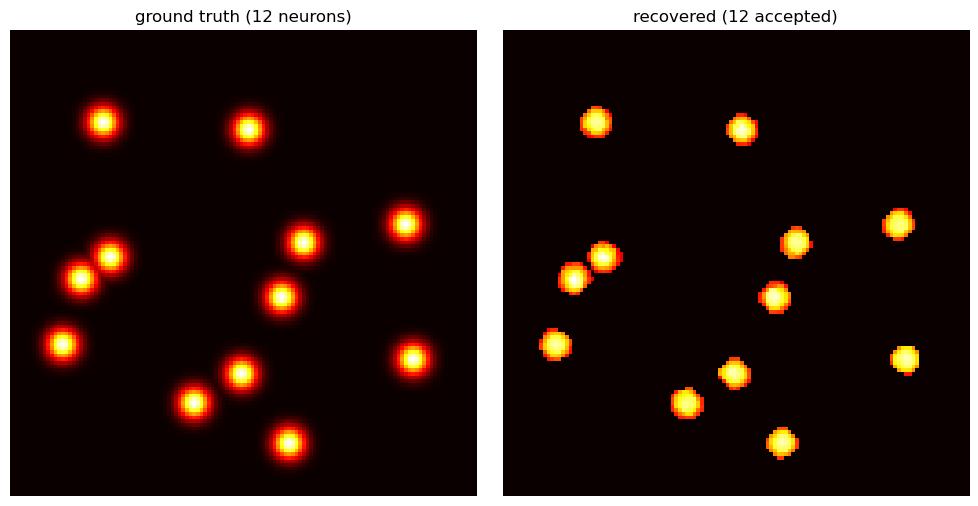

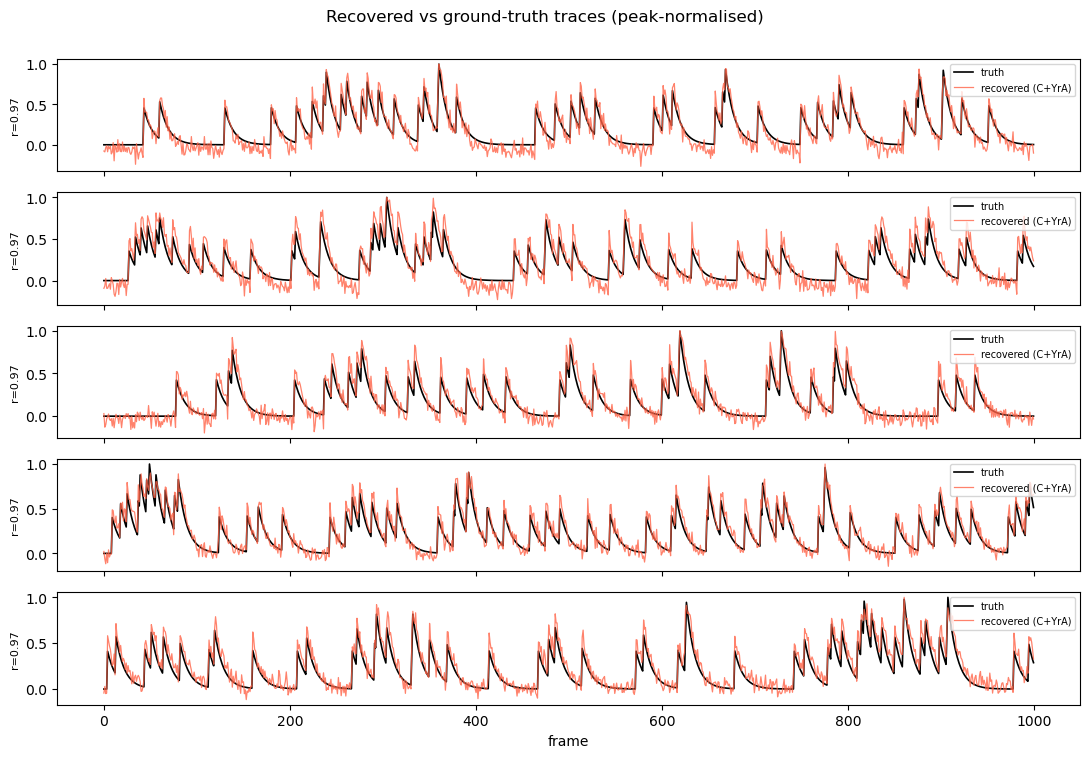

In [10]:
# Recovered vs true footprint max-projections, side by side.
A_acc_img = A_acc.reshape(H, W, -1).max(axis=2)
A_true_img = A_true.reshape(H, W, -1).max(axis=2)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(A_true_img, cmap="hot"); axes[0].set_title(f"ground truth ({G} neurons)"); axes[0].axis("off")
axes[1].imshow(A_acc_img, cmap="hot"); axes[1].set_title(f"recovered ({len(acc)} accepted)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

# A few recovered-vs-true trace overlays.
n_show = min(5, len(pairs))
order = np.argsort(-trace_r)[:n_show]
fig, axes = plt.subplots(n_show, 1, figsize=(11, 1.5 * n_show), sharex=True)
for ax, idx in zip(np.atleast_1d(axes), order):
    g, k, c, r = pairs[idx]
    t = np.arange(C_true.shape[1])
    ax.plot(t, C_true[g] / C_true[g].max(), color="black", lw=1.2, label="truth")
    ax.plot(t, C_acc[k] / C_acc[k].max(), color="tomato", lw=0.9, alpha=0.8, label="recovered (C+YrA)")
    ax.set_ylabel(f"r={r:.2f}", fontsize=8)
    ax.legend(loc="upper right", fontsize=7)
np.atleast_1d(axes)[-1].set_xlabel("frame")
plt.suptitle("Recovered vs ground-truth traces (peak-normalised)", y=1.005)
plt.tight_layout(); plt.show()

## 8. Save results to disk

In [11]:
# Writes A.npz, C.npy, S.npy, YrA.npy, sn.npy, b0.npy, W.npz, g.npy,
# sn_per_k.npy, A_norm.npy, accepted_mask.npy, eval_info.npz, params.json, ...
model.save(OUTPUT_DIR)

run_info = {
    "movie": str(ZARR_PATH),
    "movie_shape": list(movie.shape),
    "K_extracted": int(K),
    "K_accepted": int(n_acc),
    "recall": f"{len(pairs)}/{G}",
    "median_trace_r": round(float(np.median(trace_r)), 3),
    "wall_time_s": round(fit_elapsed, 2),
}
(OUTPUT_DIR / "run_info.json").write_text(json.dumps(run_info, indent=2))

print(f"Results saved to {rel(OUTPUT_DIR)}/")
for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file():
        print(f"  {p.name:18s} {p.stat().st_size / 1e6:7.2f} MB")
print("\nReload anywhere with:")
print(f"  model = CNMFe.load('{rel(OUTPUT_DIR)}')")
print( "  C_proj = model.C_projected   # = model.C + model.YrA")

Results saved to demo_movies/simple_medium_results/
  A.npz                 0.00 MB
  A_norm.npy            0.00 MB
  C.npy                 0.05 MB
  C_raw.npy             0.05 MB
  S.npy                 0.05 MB
  W.npz                 4.33 MB
  YrA.npy               0.05 MB
  accepted_mask.npy     0.00 MB
  b0.npy                0.07 MB
  eval_info.npz         0.00 MB
  g.npy                 0.00 MB
  manifest.json         0.00 MB
  params.json           0.00 MB
  run_info.json         0.00 MB
  sn.npy                0.07 MB
  sn_per_k.npy          0.00 MB

Reload anywhere with:
  model = CNMFe.load('demo_movies/simple_medium_results')
  C_proj = model.C_projected   # = model.C + model.YrA


## 9. What's next

- **Part 4** (`04_advanced_features.ipynb`) covers the production knobs:
  downsample-once extraction, region cutouts, dense-FOV footprint tightening,
  and the rank-1 global background for long, drifting recordings.
- **Reload** results with `CNMFe.load(OUTPUT_DIR)`; the params are restored on
  `model.params` and the accept/reject tags on `model.accepted_mask`.
- **Re-tune the auto-eval** without re-extracting: change `min_pixel` /
  `auto_eval_snr_amp_thr` on a loaded model and call `model.evaluate()` again
  (it reads only `A` and `sn`).

## 10. Optional — streaming extraction for 60k+ frame recordings

When the movie is too large to hold in RAM, pass `output_dir=` to `fit()`. The
pipeline transposes the corrected zarr to an on-disk **pixel-major** store
(`<output_dir>/Y_flat_pixel.zarr`, idempotent) and streams the whole BCD loop
against it — peak RAM is bounded by `K · T · 4` plus per-batch buffers,
independent of the frame count. Same params; `n_jobs=-1` keeps every step
parallel, including the streaming ring-background solve.

In [12]:
# Drop-in alternative to cells 2 + 5 for a movie that won't fit in RAM.
# Here the movie is tiny, so this just demonstrates the call shape. The
# pixel-major store is auto-derived under output_dir (we use a scratch dir).
# We silence the verbose per-stage log here — cell 5 already showed it.
import contextlib
import io
import shutil
import tempfile

z3d = open_zarr(ZARR_PATH)
stream_out = Path(tempfile.mkdtemp())
stream_model = CNMFe(params)
with contextlib.redirect_stdout(io.StringIO()):
    stream_model.fit(z3d, do_motion_correction=False, output_dir=stream_out)
print(f"streaming fit: {stream_model.A.shape[1]} components "
      f"({int(stream_model.accepted_mask.sum())} accepted)")
print("pixel-major store auto-derived at <output_dir>/Y_flat_pixel.zarr "
      "(peak RAM bounded by K*T*4, independent of frame count)")
shutil.rmtree(stream_out, ignore_errors=True)

# Manual control over chunking / destination:
# from minicnmfe import transpose_zarr_to_pixel_major
# transpose_zarr_to_pixel_major(ZARR_PATH, out_dir / "mc_pixel.zarr",
#                               pixel_chunk=512, skip_if_exists=True)

transpose:   0%|          | 0/1 [00:00<?, ?it/s]

transpose: 100%|██████████| 1/1 [00:00<00:00,  5.15it/s]

transpose: 100%|██████████| 1/1 [00:00<00:00,  5.14it/s]

streaming fit: 12 components (12 accepted)
pixel-major store auto-derived at <output_dir>/Y_flat_pixel.zarr (peak RAM bounded by K*T*4, independent of frame count)
